# Deep Learning Multiclass Classification


In [60]:
# !python -m pip install numpy pandas \
#     qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
#     pylatexenc ucimlrepo \
#     xgboost catboost seaborn libsvm-official \
#     jinja2 \
#     scikit-optimize imbalanced-learn

```mermaid
flowchart TD
    A[("Dataset_TehHijau.csv")] --> B[Load data]
    B --> C[X = 12 sensor + Humidity + Celsius]
    B --> D[y = LabelEncoder]
    C --> E[StandardScaler -> PCA n_optimal]
    E --> F{{"StratifiedKFold 5-fold CV<br/>shuffle, random_state=42"}}
    F -->|train fold| G[["SMOTEENN (train fold only)"]]
    G --> H["Train MLP / 1D CNN<br/>EarlyStopping di val fold"]
    F -->|val fold| H
    H --> I["Prediksi val fold → kumpulkan OOF<br/>(seluruh data terprediksi 1×)"]
    I --> J["Metrik mean±std + OOF<br/>Acc, F1, ROC-AUC, PR-AUC, Loss, MCC"]
    J --> K[best_result -> all_best]
    K --> L[("results/checkpoints/dl_all_best_*.pkl")]
    K --> M[Tabel evaluasi + confusion matrix OOF + learning curve]
    L --> N["!results.ipynb (family Deep Learning)"]
```


## Utility Function

In [61]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/dl/best_param")
log_dir.mkdir(parents=True, exist_ok=True)
Path("./results/images").mkdir(parents=True, exist_ok=True)
Path("./results/csv").mkdir(parents=True, exist_ok=True)

def config_slug():
  """Slug ringkas konfigurasi skenario (DROP_CLASSES + resampling) -> beda
  nama log & checkpoint antar-konfigurasi."""
  import re
  parts = []
  if DROP_CLASSES:
    parts.append("drop" + "".join(sorted(map(str, DROP_CLASSES))))
  if not CUSTOM_TARGETS:
    parts.append("noresample")
  else:
    t = CUSTOM_TARGETS if isinstance(CUSTOM_TARGETS, str) else \
        "-".join(f"{k}{v}" for k, v in sorted(CUSTOM_TARGETS.items()))
    parts.append(f"{t}_{OVER_METHOD}_{UNDER_METHOD}")
  return re.sub(r"[^A-Za-z0-9._-]+", "-", "_".join(parts) if parts else "default")

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'mlp', 'cnn1d'."""
  global _current_log_path
  _current_log_path = log_dir / f"dl_{name}_{config_slug()}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [62]:
import sys
import os
import pandas as pd
import warnings
import sys
import importlib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("quantum-multiclass-classification")[0] + "quantum-multiclass-classification"
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

# Test import module
from utils.prepare_data import prepare_data

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")


Project root: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification


## 1. Load & Split Dataset

In [63]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

# ── ⚙️ Skenario Eksperimen ──────────────────────────────────
# DROP_CLASSES   : label kelas (nilai asli kolom target) yang dibuang sebelum split.
#                  Contoh ["B"] -> buang kelas B. [] = pakai semua kelas.
# CUSTOM_TARGETS : target jumlah per-kelas saat resample (dihitung per fold, train fold only):
#                  {} = tanpa resampling. nilai = int (jumlah absolut) ATAU nama kelas lain
#                  (samakan jumlahnya), mis. {"B": "C", "E": "C"}. Kelas tak disebut = dibiarkan.
#                  "auto-over"  = full oversampling (semua ke mayoritas);
#                  "auto-under" = full undersampling (semua ke minoritas).
# OVER_METHOD    : teknik oversampling -> 'smote' | 'borderline' | 'smoteenn' | 'smotetomek'
# UNDER_METHOD   : teknik undersampling -> 'random' (target eksak) | 'tomek' (cleaning)
DROP_CLASSES   = ['B']
CUSTOM_TARGETS = {'E': 'C'}  # contoh: resample kelas E jadi sebanyak kelas C
OVER_METHOD    = "smoteenn"
UNDER_METHOD   = "random"


### 1.1 Exploratory Data Analysis

In [64]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0000,43.0000,46.0000,133.0000,97.0000,46.0000,552.0000,289.0000,546.0000,371.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
1,90.0000,42.0000,47.0000,133.0000,96.0000,47.0000,551.0000,290.0000,547.0000,371.0000,46.5000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
2,89.0000,42.0000,47.0000,133.0000,97.0000,45.0000,553.0000,291.0000,547.0000,369.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.700

In [65]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000
mean,89.4148,47.6007,47.9362,98.2916,89.1822,51.5488,533.6701,213.7386,531.1246,330.5003,48.3877,39.6567,2.9351,34.8889,3.0354,3.1353,3.0719,89.4012,88.0726,90.8381,0.9831,0.0311,-0.4979,797.2830,51.3814,46.4283,86.3774,12.7680,0.0479,-0.7677,461.0916,48.9235,46.6657,56.4011,3.4174,0.0421,-0.7428,435.5016,98.3196,97.1902,99.9750,0.9774,0.1539,-0.3362,872.0037,89.1671,87.8391,90.5666,0.9752,0.0541,-0.7782,790.1031,52.0472,50.2007,56.9313,2.4119,0.0111,-0.7795,460.3774,533.5854,530.4756,535.6482,1.7161,-0.2305,-0.6140,4754.9384,215.5427,212.0394,231.5642,6.5498,-0.0593,-0.6575,1919.9904,531.0398,529.3107,532.0894,1.0005,-0.0311,-0.8901,4742.8424,330.4472,328.8314,331.6405,0.9806,0.0223,-0.7770,2953.2800,4077.8091,48.1753,40342.7838,12742.2929,-0.0207,-0.4484,40727.0018,39.6562,39.5960,39.7184,0.0507,-0.0031,0.0236,355.6654,2.9351,2.9351,2.9351,0.0000,26.4163,34.8889,34.8889,34.8889,0.0000,314.0005,3.0354,3.0354,3.0354,0.0000,27.3184,3.1353,3.1353,3.1353,0.0000,28.2178,3.0719,3.0719,3.0719,0.0000,27.6469
std,3.6692,4.6781,4.6166,15.8494,4.2090,4.9676,7.0074,24.6137,5.5522,12.9071,3.1265,1.3128,0.2578,1.7327,0.2553,0.2705,0.3078,4.2821,7.6516,21.2644,7.0327,0.8407,1.5014,52.9311,134.

Text(0.5, 1.0, 'Histogram for the Kategori')

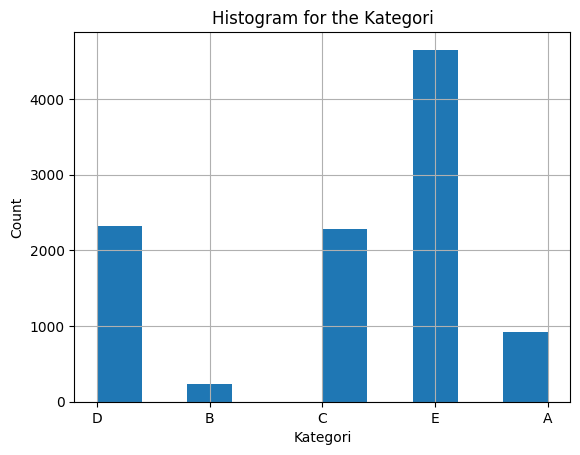

In [66]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

### 1.2 Split Data

In [67]:
# ⚙️ Skenario: drop kelas sesuai DROP_CLASSES (lihat config di Bagian 1)
if DROP_CLASSES:
    _before = len(data)
    data = data[~data[target_cols].isin(DROP_CLASSES)].reset_index(drop=True)
    print(f"🗑️  Drop kelas {DROP_CLASSES}: {_before} → {len(data)} baris")
print("Distribusi kelas:", dict(data[target_cols].value_counts().sort_index()))

X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

🗑️  Drop kelas ['B']: 10409 → 10180 baris
Distribusi kelas: {'A': np.int64(927), 'C': np.int64(2287), 'D': np.int64(2317), 'E': np.int64(4649)}
(10180, 12) (10180,)


### 1.3 Encode Categorical Data (y = Kategori)

In [68]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

### 1.4 PCA Variance Analysis (threshold = 0.95)

In [69]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

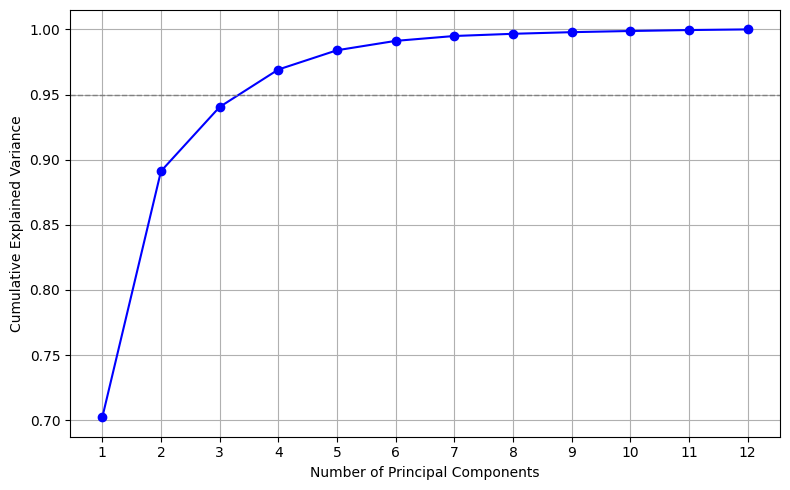

Optimal number of components to retain 95% variance: 4


In [70]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

### 1.5 Komposisi Dataset (Sebelum vs Sesudah SMOTEENN)

Data di-oversampling pakai SMOTE dulu, trus nanti kan pasti ada noise, itu dibersihin pake ENN. ENN ini konsepnya ngecek tetangga terdekat dari data sintesis maupun data asli itu banyak yg sama atau nggak, misal datanya kelass B. Tetangganya mayoritas kelas B atau tidak. Kalau minoritas berarti dibuang. Kalau mayoritas disimpan

Komposisi kelas (full data, ilustrasi):


,Sebelum,Sesudah,Δ
A,927,927,0
C,2287,2287,0
D,2317,2317,0
E,4649,2287,-2362
TOTAL,10180,7818,-2362


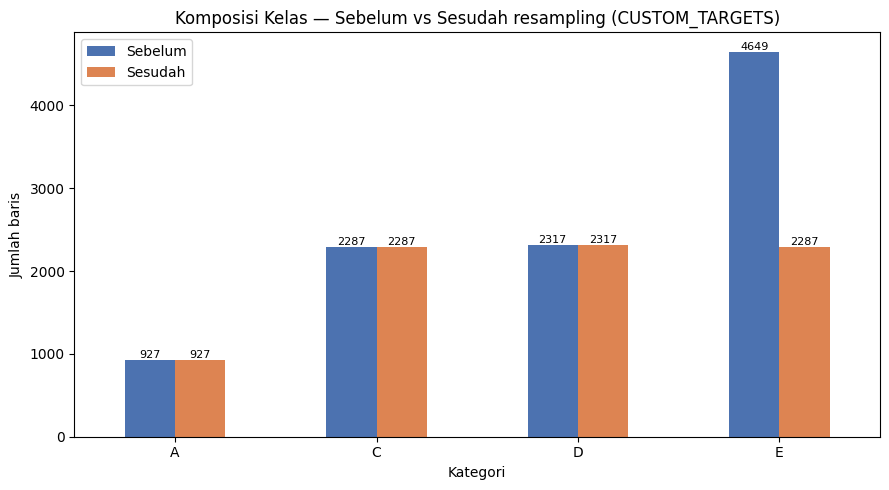

✅ Saved: ./results/images/composition_before_after_smoteenn.png


In [71]:
# ════════════════════════════════════════════════════════════
# 🔁 Komposisi kelas: SEBELUM vs SESUDAH SMOTEENN
# ════════════════════════════════════════════════════════════
# SMOTEENN diterapkan di ruang (StandardScaler → PCA), sama seperti di dalam CV.
# Di CV resampling hanya pada fold training; di sini full data dipakai semata
# sebagai ILUSTRASI efek resampling terhadap komposisi kelas.
from collections import Counter
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

class_names = list(label_encoder.classes_)

_Xp = PCA(n_components=n_optimal).fit_transform(StandardScaler().fit_transform(X))
if CUSTOM_TARGETS:
    from utils.imbalance_eval import make_custom_resampler
    _res = make_custom_resampler(CUSTOM_TARGETS, list(label_encoder.classes_),
                                 over_method=OVER_METHOD, under_method=UNDER_METHOD)
    _Xr, _yr = _res.fit_resample(_Xp, y)
else:
    _Xr, _yr = _Xp, y

_before, _after = Counter(y), Counter(_yr)
comp = pd.DataFrame({
    "Sebelum": [int(_before.get(i, 0)) for i in range(len(class_names))],
    "Sesudah": [int(_after.get(i, 0)) for i in range(len(class_names))],
}, index=class_names)
comp["Δ"] = comp["Sesudah"] - comp["Sebelum"]
comp.loc["TOTAL"] = comp.sum()
print("Komposisi kelas (full data, ilustrasi):")
display(comp)

ax = comp.drop(index="TOTAL")[["Sebelum", "Sesudah"]].plot(
    kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Komposisi Kelas — Sebelum vs Sesudah resampling (CUSTOM_TARGETS)")
ax.set_xlabel("Kategori"); ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.tight_layout()
import os
os.makedirs("./results/images", exist_ok=True)
os.makedirs("./results/csv", exist_ok=True)
plt.savefig("./results/images/composition_before_after_smoteenn.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Saved: ./results/images/composition_before_after_smoteenn.png")

## 2. Model Evaluation

### 2.0 DL hold-out runner


In [72]:
# ── DL 5-fold CV runner ─────────────────────────────────────────────────────
# Deep learning dievaluasi dengan StratifiedKFold 5-fold CV (protokol SAMA dengan
# model klasik/QML), mengumpulkan prediksi out-of-fold (OOF) seluruh data →
# metrik mean±std + confusion matrix OOF. Tiap fold: Scaler→PCA→SMOTEENN(train fold)
# →model.fit(early stopping di val)→predict val. best_result KOMPATIBEL dgn !results.ipynb.
import os, time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, precision_score, recall_score, log_loss, classification_report,
    balanced_accuracy_score,
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
for _g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(_g, True)
    except Exception:
        pass

classes   = np.unique(y)
n_classes = int(len(classes))
L2 = 1e-4   # weight decay (anti-overfit). Imbalance ditangani SMOTEENN tiap train fold.
print(f"TF {tf.__version__} | GPU: {len(tf.config.list_physical_devices('GPU'))} | n_classes={n_classes}")


def make_resampler():
    """Resampler kustom per-kelas (CUSTOM_TARGETS) via utils.imbalance_eval.
    None bila CUSTOM_TARGETS kosong. Di-fit per fold (train fold only, no leak)."""
    if not CUSTOM_TARGETS:
        return None
    from utils.imbalance_eval import make_custom_resampler
    return make_custom_resampler(
        CUSTOM_TARGETS, list(label_encoder.classes_),
        over_method=OVER_METHOD, under_method=UNDER_METHOD)


def prep_fold(train_idx, val_idx, conv=False, resampler=None):
    """Scaler + PCA di-fit di train fold; transform val fold (no leak).
    Resample train fold saja (opsional Conv reshape)."""
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_va = X.iloc[val_idx],   y[val_idx]
    sc = StandardScaler(); X_tr_s = sc.fit_transform(X_tr); X_va_s = sc.transform(X_va)
    pca = PCA(n_components=n_optimal); X_tr_p = pca.fit_transform(X_tr_s); X_va_p = pca.transform(X_va_s)
    if resampler is not None:
        X_tr_fit, y_tr_fit = resampler.fit_resample(X_tr_p, y_tr)
    else:
        X_tr_fit, y_tr_fit = X_tr_p, y_tr
    if conv:
        X_tr_fit = X_tr_fit[..., np.newaxis]; X_va_p = X_va_p[..., np.newaxis]
    return X_tr_fit, y_tr_fit, X_va_p, y_va


def build_mlp(input_dim, n_classes, params):
    keras.utils.set_random_seed(SEED)
    inp = keras.Input(shape=(input_dim,)); x = inp
    for h in params['hidden_units']:
        x = layers.Dense(h, activation='relu', kernel_initializer='he_normal',
                         kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(params['dropout'])(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_cnn1d(input_len, n_classes, params):
    keras.utils.set_random_seed(SEED)
    inp = keras.Input(shape=(input_len, 1)); x = inp
    for f in params['filters']:
        x = layers.Conv1D(f, kernel_size=params['kernel_size'], padding='same',
                          activation='relu', kernel_initializer='he_normal',
                          kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        if x.shape[1] is not None and x.shape[1] > 1:
            x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(params['dropout'])(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(params['dropout'])(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def evaluate_cv(model_name, log_name, build_fn, params, conv, csv_name,
                n_splits=5, state=42, results_dir="./results/csv/best_param/"):
    """5-fold StratifiedKFold CV untuk satu konfigurasi DL. Kumpulkan prediksi OOF
    seluruh data; rekam best_result (mean±std + OOF) ke all_best."""
    setup_logger(log_name)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)
    _cls_names = [str(c) for c in label_encoder.classes_]
    tag = " | ".join(f"{k}={v}" for k, v in params.items())
    log(f"🔬 {model_name} | {tag} | StratifiedKFold {n_splits}-fold CV (OOF)")
    t0 = time.perf_counter()

    accs, precs, recs, f1s, rocs, pras, lls = [], [], [], [], [], [], []
    baccs, precws, recws, f1ws = [], [], [], []
    y_val_all, y_pred_all = [], []
    y_prob_all = []   # OOF probabilities -> kurva ROC/PR
    hist_last = None
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr_fit, y_tr_fit, X_va, y_va = prep_fold(
            tr_idx, va_idx, conv=conv, resampler=make_resampler())

        keras.backend.clear_session()
        model = build_fn(X_tr_fit.shape[1], n_classes, params)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                           restore_best_weights=True, verbose=0)
        h = model.fit(X_tr_fit, y_tr_fit, validation_data=(X_va, y_va),
                      epochs=params['epochs'], batch_size=params['batch_size'],
                      verbose=0, callbacks=[es])
        hist_last = {k: [float(v) for v in h.history[k]] for k in h.history}

        y_prob = model.predict(X_va, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_val_all.extend(list(map(int, y_va)))
        y_pred_all.extend(list(map(int, y_pred)))
        y_prob_all.append(np.asarray(y_prob))

        acc  = accuracy_score(y_va, y_pred)
        prec = precision_score(y_va, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_va, y_pred, average="macro")
        f1   = f1_score(y_va, y_pred, average="macro")
        roc  = roc_auc_score(y_va, y_prob, average="macro", multi_class="ovr")
        pra  = average_precision_score(y_va, y_prob, average="macro")
        ll   = log_loss(y_va, y_prob, labels=classes)
        accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1)
        rocs.append(roc); pras.append(pra); lls.append(ll)
        baccs.append(balanced_accuracy_score(y_va, y_pred))
        precws.append(precision_score(y_va, y_pred, average="weighted", zero_division=0))
        recws.append(recall_score(y_va, y_pred, average="weighted"))
        f1ws.append(f1_score(y_va, y_pred, average="weighted"))
        log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | "
            f"AUROC={roc:.4f} | PRAUC={pra:.4f} | Loss={ll:.4f}")
        _rep_df = pd.DataFrame(classification_report(
            y_va, y_pred, labels=classes, target_names=_cls_names,
            zero_division=0, output_dict=True)).T
        _rep_df["support"] = _rep_df["support"].astype(int)
        _rep_df = _rep_df.round(4)
        print(f"    📋 Classification report F{fold}:")
        display(_rep_df)
        if _current_log_path is not None:
            with open(_current_log_path, "a", encoding="utf-8") as _f:
                _f.write(f"    📋 Classification report F{fold}:\n")
                _f.write(_rep_df.to_string() + "\n")

    acc_m, acc_s   = np.mean(accs),  np.std(accs)
    prec_m, prec_s = np.mean(precs), np.std(precs)
    rec_m, rec_s   = np.mean(recs),  np.std(recs)
    f1_m, f1_s     = np.mean(f1s),   np.std(f1s)
    roc_m, roc_s   = np.mean(rocs),  np.std(rocs)
    pra_m, pra_s   = np.mean(pras),  np.std(pras)
    loss_m, loss_s = np.mean(lls),   np.std(lls)
    mcc = matthews_corrcoef(y_val_all, y_pred_all)
    bacc_m, bacc_s   = np.mean(baccs),  np.std(baccs)
    precw_m, precw_s = np.mean(precws), np.std(precws)
    recw_m, recw_s   = np.mean(recws),  np.std(recws)
    f1w_m, f1w_s     = np.mean(f1ws),   np.std(f1ws)
    composite = (roc_m + pra_m + acc_m) / 3

    log(
        f"  ✅  Acc:{acc_m:.4f}±{acc_s:.4f} | Prec:{prec_m:.4f}±{prec_s:.4f} | "
        f"Rec:{rec_m:.4f}±{rec_s:.4f} | F1:{f1_m:.4f}±{f1_s:.4f} | "
        f"AUROC:{roc_m:.4f}±{roc_s:.4f} | PRAUC:{pra_m:.4f}±{pra_s:.4f} | "
        f"Loss:{loss_m:.4f}±{loss_s:.4f} | MCC:{mcc:.4f} | Composite:{composite:.4f}"
    )

    iter_time = time.perf_counter() - t0
    best_result = {
        "tag": tag, "model": model_name, "composite": composite,
        "acc":  f"{acc_m:.4f}±{acc_s:.4f}",  "prec": f"{prec_m:.4f}±{prec_s:.4f}",
        "rec":  f"{rec_m:.4f}±{rec_s:.4f}",   "f1":   f"{f1_m:.4f}±{f1_s:.4f}",
        "roc":  f"{roc_m:.4f}±{roc_s:.4f}",   "pra":  f"{pra_m:.4f}±{pra_s:.4f}",
        "loss": f"{loss_m:.4f}±{loss_s:.4f}", "mcc":  f"{mcc:.4f}",
        "bal_acc": f"{bacc_m:.4f}±{bacc_s:.4f}", "prec_w": f"{precw_m:.4f}±{precw_s:.4f}",
        "rec_w": f"{recw_m:.4f}±{recw_s:.4f}", "f1_w": f"{f1w_m:.4f}±{f1w_s:.4f}",
        "params": params, "execution_time": iter_time,
        # Prediksi OOF seluruh data -> confusion matrix & per-class metrics di !results.ipynb
        "y_true": y_val_all, "y_pred": y_pred_all,
        "y_prob": np.vstack(y_prob_all),
        "history": hist_last,   # history fold terakhir (untuk learning curve)
    }
    best_result["report_text"] = classification_report(
        y_val_all, y_pred_all, labels=classes, target_names=_cls_names, zero_division=0)
    best_result["report_dict"] = classification_report(
        y_val_all, y_pred_all, labels=classes, target_names=_cls_names,
        output_dict=True, zero_division=0)
    log(""); log("=" * 60)
    log(f"📋 Classification report (OOF) — {model_name}:"); log("=" * 60)
    log(best_result["report_text"])

    os.makedirs(results_dir, exist_ok=True)
    pd.DataFrame([{
        "tag": tag, **params, "accuracy": acc_m, "precision": prec_m, "recall": rec_m,
        "F1": f1_m, "auroc": roc_m, "prauc": pra_m, "loss": loss_m, "mcc": mcc,
    }]).to_csv(os.path.join(results_dir, csv_name), index=False)

    all_best.append(dict(best_result))
    log(f"✅ [{model_name}] recorded | Exec. time: {iter_time:.1f}s")
    return best_result


def build_eval_table(all_best):
    """Tabel evaluasi: row = model, column = metrik (mean±std)."""
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Log-Loss'       : r.get('loss', 'N/A'),
            'MCC'            : r.get('mcc', 'N/A'),
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df


TF 2.21.0 | GPU: 0 | n_classes=4


### 2.0.1 Checkpoint (resume lintas restart kernel)

`all_best` disimpan ke disk setiap satu model selesai, dan dimuat ulang saat rerun — model yang sudah kelar otomatis **dilewati**. Set `RESET_CHECKPOINT = True` lalu jalankan sel ini untuk mulai dari nol.

In [ ]:
# ════════════════════════════════════════════════════════════
# 💾 Checkpoint — resume eval lintas restart kernel
# ════════════════════════════════════════════════════════════
# Hasil tiap model (all_best) disimpan ke disk setelah selesai, dan dimuat ulang
# saat rerun. evaluate_cv dibungkus agar:
#   - model yang sudah ada di checkpoint -> DILEWATI (pakai hasil tersimpan)
#   - tiap model selesai -> checkpoint langsung ditulis (aman bila kernel mati)
# File: dl_all_best_{slug}.pkl  -> dimuat oleh !results.ipynb (family Deep Learning).
import os
import pickle

CKPT_PATH        = f"./results/checkpoints/dl_all_best_{config_slug()}.pkl"
RESET_CHECKPOINT = False   # True = hapus checkpoint & mulai dari nol

os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)


def save_checkpoint(obj, path=CKPT_PATH):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"💾 Checkpoint disimpan → {path} ({len(obj)} model)")


def load_checkpoint(path=CKPT_PATH):
    if os.path.exists(path):
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"♻️  Checkpoint dimuat ← {path} "
              f"({len(obj)} model: {[r['model'] for r in obj]})")
        return obj
    print("ℹ️  Belum ada checkpoint — mulai baru.")
    return []


if RESET_CHECKPOINT and os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("🗑️  Checkpoint dihapus (RESET_CHECKPOINT=True)")

# Resume: muat hasil model yang sudah selesai ke all_best
all_best = load_checkpoint()

# Bungkus evaluate_cv (sekali saja) -> skip model selesai + autosave tiap selesai
if not getattr(evaluate_cv, "_ckpt_wrapped", False):
    _evaluate_cv_inner = evaluate_cv

    def evaluate_cv(model_name, *args, **kwargs):
        done = {r["model"] for r in all_best}
        if model_name in done:
            print(f"⏭️  [{model_name}] sudah ada di checkpoint — dilewati "
                  f"(set RESET_CHECKPOINT=True utk ulang).")
            return next(r for r in all_best if r["model"] == model_name)
        res = _evaluate_cv_inner(model_name, *args, **kwargs)
        save_checkpoint(all_best)
        return res

    evaluate_cv._ckpt_wrapped = True

print(f"✅ Checkpoint siap. Model selesai: {[r['model'] for r in all_best]}")


ℹ️  Belum ada checkpoint — mulai baru.
✅ Checkpoint siap. Model selesai: []


### 2.1 MLP


In [74]:
# Best params dari notebooks/hpo/dl/mlp.ipynb (5-fold StratifiedKFold CV).
mlp_params = {
    'hidden_units' : (128, 64, 32),
    'dropout'      : 0.2,
    'learning_rate': 0.001,
    'batch_size'   : 64,
    'epochs'       : 100,
}
evaluate_cv(
    model_name="MLP",
    log_name="mlp",
    build_fn=build_mlp,
    params=mlp_params,
    conv=False,
    csv_name="mlp_hpo.csv",
);


📝 Log: results\logs\dl\best_param\dl_mlp_dropB_EC_smoteenn_random_hpo.log
🕒 Started: 2026-06-11T10:40:56
🔬 MLP | hidden_units=(128, 64, 32) | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100 | StratifiedKFold 5-fold CV (OOF)
    F1 → Acc=0.9597 | Prec=0.9486 | Rec=0.9568 | F1=0.9521 | AUROC=0.9978 | PRAUC=0.9907 | Loss=0.1124
    📋 Classification report F1:


,precision,recall,f1-score,support
A,0.9392,0.9189,0.9290,185
C,0.9162,0.9803,0.9471,457
D,0.9401,0.9806,0.9599,464
E,0.9989,0.9473,0.9724,930
accuracy,0.9597,0.9597,0.9597,0
macro avg,0.9486,0.9568,0.9521,2036
weighted avg,0.9615,0.9597,0.9599,2036


    F2 → Acc=0.9671 | Prec=0.9551 | Rec=0.9584 | F1=0.9563 | AUROC=0.9982 | PRAUC=0.9899 | Loss=0.0994
    📋 Classification report F2:


,precision,recall,f1-score,support
A,0.9326,0.8973,0.9146,185
C,0.9413,0.9825,0.9615,457
D,0.9486,0.9935,0.9705,464
E,0.9978,0.9602,0.9786,930
accuracy,0.9671,0.9671,0.9671,0
macro avg,0.9551,0.9584,0.9563,2036
weighted avg,0.9680,0.9671,0.9671,2036


    F3 → Acc=0.9666 | Prec=0.9557 | Rec=0.9648 | F1=0.9601 | AUROC=0.9984 | PRAUC=0.9925 | Loss=0.0917
    📋 Classification report F3:


...

    F4 → Acc=0.9632 | Prec=0.9480 | Rec=0.9576 | F1=0.9526 | AUROC=0.9969 | PRAUC=0.9829 | Loss=0.1051
    📋 Classification report F4:


,precision,recall,f1-score,support
A,0.9101,0.9247,0.9173,186
C,0.9444,0.9651,0.9546,458
D,0.9418,0.9784,0.9597,463
E,0.9955,0.9623,0.9787,929
accuracy,0.9632,0.9632,0.9632,0
macro avg,0.9480,0.9576,0.9526,2036
weighted avg,0.9640,0.9632,0.9634,2036


    F5 → Acc=0.9671 | Prec=0.9548 | Rec=0.9593 | F1=0.9569 | AUROC=0.9987 | PRAUC=0.9937 | Loss=0.0822
    📋 Classification report F5:


,precision,recall,f1-score,support
A,0.9290,0.9140,0.9214,186
C,0.9430,0.9781,0.9603,457
D,0.9517,0.9784,0.9649,463
E,0.9956,0.9667,0.9809,930
accuracy,0.9671,0.9671,0.9671,0
macro avg,0.9548,0.9593,0.9569,2036
weighted avg,0.9677,0.9671,0.9672,2036


  ✅  Acc:0.9647±0.0029 | Prec:0.9524±0.0034 | Rec:0.9594±0.0029 | F1:0.9556±0.0029 | AUROC:0.9980±0.0006 | PRAUC:0.9899±0.0037 | Loss:0.0982±0.0105 | MCC:0.9488 | Composite:0.9842

📋 Classification report (OOF) — MLP:
              precision    recall  f1-score   support

           A       0.93      0.92      0.92       927
           C       0.94      0.97      0.96      2287
           D       0.95      0.98      0.96      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.96     10180
   macro avg       0.95      0.96      0.96     10180
weighted avg       0.97      0.96      0.96     10180

✅ [MLP] recorded | Exec. time: 248.0s
💾 Checkpoint disimpan → ./results/checkpoints/dl_all_best_dropB_EC_smoteenn_random.pkl (1 model)


### 2.2 1D CNN


In [75]:
# Best params dari notebooks/hpo/dl/cnn1d.ipynb (5-fold StratifiedKFold CV).
cnn1d_params = {
    'filters'      : (64, 128),
    'kernel_size'  : 3,
    'dropout'      : 0.2,
    'learning_rate': 0.001,
    'batch_size'   : 64,
    'epochs'       : 100,
}
evaluate_cv(
    model_name="1D CNN",
    log_name="cnn1d",
    build_fn=build_cnn1d,
    params=cnn1d_params,
    conv=True,
    csv_name="cnn1d_hpo.csv",
);


📝 Log: results\logs\dl\best_param\dl_cnn1d_dropB_EC_smoteenn_random_hpo.log
🕒 Started: 2026-06-11T10:45:04
🔬 1D CNN | filters=(64, 128) | kernel_size=3 | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100 | StratifiedKFold 5-fold CV (OOF)
    F1 → Acc=0.9602 | Prec=0.9403 | Rec=0.9639 | F1=0.9510 | AUROC=0.9984 | PRAUC=0.9925 | Loss=0.0934
    📋 Classification report F1:


,precision,recall,f1-score,support
A,0.8775,0.9676,0.9203,185
C,0.9187,0.9891,0.9526,457
D,0.9649,0.9483,0.9565,464
E,1.0000,0.9505,0.9746,930
accuracy,0.9602,0.9602,0.9602,0
macro avg,0.9403,0.9639,0.9510,2036
weighted avg,0.9626,0.9602,0.9606,2036


    F2 → Acc=0.9661 | Prec=0.9543 | Rec=0.9606 | F1=0.9570 | AUROC=0.9982 | PRAUC=0.9902 | Loss=0.0935
    📋 Classification report F2:


,precision,recall,f1-score,support
A,0.9333,0.9081,0.9205,185
C,0.9337,0.9869,0.9596,457
D,0.9525,0.9935,0.9726,464
E,0.9978,0.9538,0.9753,930
accuracy,0.9661,0.9661,0.9661,0
macro avg,0.9543,0.9606,0.9570,2036
weighted avg,0.9672,0.9661,0.9662,2036


    F3 → Acc=0.9651 | Prec=0.9502 | Rec=0.9662 | F1=0.9579 | AUROC=0.9987 | PRAUC=0.9943 | Loss=0.0826
    📋 Classification report F3:


...

    F4 → Acc=0.9666 | Prec=0.9497 | Rec=0.9654 | F1=0.9572 | AUROC=0.9979 | PRAUC=0.9890 | Loss=0.0933
    📋 Classification report F4:


,precision,recall,f1-score,support
A,0.8905,0.9624,0.9251,186
C,0.9570,0.9716,0.9642,458
D,0.9590,0.9590,0.9590,463
E,0.9923,0.9688,0.9804,929
accuracy,0.9666,0.9666,0.9666,0
macro avg,0.9497,0.9654,0.9572,2036
weighted avg,0.9675,0.9666,0.9668,2036


    F5 → Acc=0.9686 | Prec=0.9529 | Rec=0.9615 | F1=0.9570 | AUROC=0.9990 | PRAUC=0.9949 | Loss=0.0691
    📋 Classification report F5:


,precision,recall,f1-score,support
A,0.9101,0.9247,0.9173,186
C,0.9474,0.9847,0.9657,457
D,0.9551,0.9654,0.9603,463
E,0.9989,0.9710,0.9847,930
accuracy,0.9686,0.9686,0.9686,0
macro avg,0.9529,0.9615,0.9570,2036
weighted avg,0.9693,0.9686,0.9687,2036


  ✅  Acc:0.9653±0.0028 | Prec:0.9495±0.0049 | Rec:0.9635±0.0022 | F1:0.9560±0.0025 | AUROC:0.9985±0.0004 | PRAUC:0.9922±0.0023 | Loss:0.0864±0.0096 | MCC:0.9497 | Composite:0.9853

📋 Classification report (OOF) — 1D CNN:
              precision    recall  f1-score   support

           A       0.90      0.94      0.92       927
           C       0.94      0.98      0.96      2287
           D       0.96      0.97      0.96      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.97     10180
   macro avg       0.95      0.96      0.96     10180
weighted avg       0.97      0.97      0.97     10180

✅ [1D CNN] recorded | Exec. time: 277.8s
💾 Checkpoint disimpan → ./results/checkpoints/dl_all_best_dropB_EC_smoteenn_random.pkl (2 model)


## 3. Final Evaluation

### 3.1 Tabel evaluasi akhir (row = model, column = metrik, mean ± std)

In [76]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# Hijau = pemenang tiap metrik | Merah = posisi terakhir
# ════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)

# Arah "lebih baik": higher-better vs lower-better (Log-Loss & waktu = makin kecil makin baik).
_higher_better = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
_lower_better  = ['Log-Loss', 'Exec. Time (s)']

def _num(v):
    try:
        return float(str(v).split('±')[0])
    except (ValueError, TypeError):
        return np.nan

def _highlight_win_lose(col):
    """Hijau utk nilai terbaik, merah utk terburuk, per kolom metrik."""
    if col.name not in _higher_better + _lower_better:
        return [''] * len(col)
    vals = col.map(_num)
    if vals.notna().sum() == 0:
        return [''] * len(col)
    if col.name in _higher_better:
        win, lose = vals.max(), vals.min()
    else:
        win, lose = vals.min(), vals.max()
    styles = []
    for v in vals:
        if v == win:
            styles.append('background-color: #b6e7b0; color: #14532d; font-weight: bold')
        elif v == lose:
            styles.append('background-color: #f4b6b6; color: #7f1d1d')
        else:
            styles.append('')
    return styles

eval_styled = eval_df.style.apply(_highlight_win_lose, axis=0)
display(eval_styled)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log-Loss,MCC,Exec. Time (s),Best Params
1,1D CNN,0.9653±0.0028,0.9495±0.0049,0.9635±0.0022,0.9560±0.0025,0.9985±0.0004,0.9922±0.0023,0.0864±0.0096,0.9497,277.840000,"filters=(64, 128) | kernel_size=3 | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100"
2,MLP,0.9647±0.0029,0.9524±0.0034,0.9594±0.0029,0.9556±0.0029,0.9980±0.0006,0.9899±0.0037,0.0982±0.0105,0.9488,247.990000,"hidden_units=(128, 64, 32) | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100"


### 3.2 Confusion matrix & per-class metrics (held-out test)


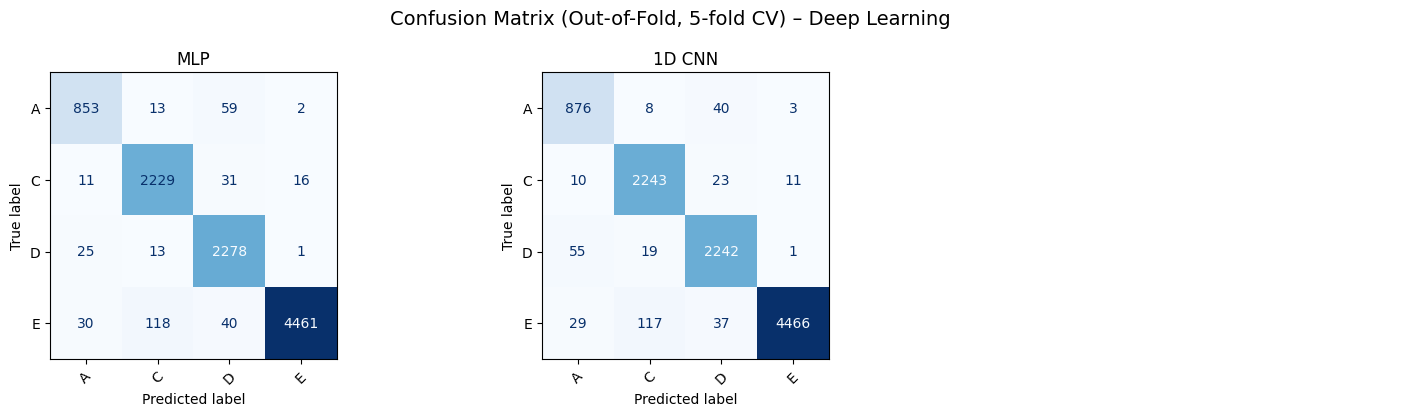

✅ Saved: ./results/images/confusion_matrix_dl_hpo.png

MLP — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.93      0.92      0.92       927
           C       0.94      0.97      0.96      2287
           D       0.95      0.98      0.96      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.96     10180
   macro avg       0.95      0.96      0.96     10180
weighted avg       0.97      0.96      0.96     10180


1D CNN — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.90      0.94      0.92       927
           C       0.94      0.98      0.96      2287
           D       0.96      0.97      0.96      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.97     10180
   macro avg       0.95      0.96      0.96     10180
weighted avg       0.97      0.97      0.97     10180



In [77]:
# ════════════════════════════════════════════════════════════
# 🔢 CONFUSION MATRIX + 📋 PER-CLASS METRICS – semua model (out-of-fold)
# ════════════════════════════════════════════════════════════
# Memakai prediksi out-of-fold (y_true/y_pred) yang dikumpulkan tiap model saat
# cross-validation → mencerminkan generalisasi, bukan performa di data training.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))

models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]
if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best. Jalankan ulang sel-sel training dulu.")
else:
    # ── Confusion matrix grid ──
    n = len(models_cm)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(r["model"])
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(models_cm):]:
        ax.axis("off")

    fig.suptitle("Confusion Matrix (Out-of-Fold, 5-fold CV) – Deep Learning", fontsize=14)
    fig.tight_layout()

    os.makedirs("./results/images", exist_ok=True)
    os.makedirs("./results/csv", exist_ok=True)
    out_path = "./results/images/confusion_matrix_dl_hpo.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

    # ── Per-class metrics: classification_report tiap model (OOF best config) ──
    # Pakai laporan yang sudah disimpan evaluate_cv; fallback hitung ulang bila perlu.
    for r in models_cm:
        print()
        print("=" * 60)
        print(f"{r['model']} — per-class metrics (OOF)")
        print("=" * 60)
        if r.get("report_text"):
            print(r["report_text"])
        else:
            print(classification_report(
                r["y_true"], r["y_pred"], labels=labels,
                target_names=class_names, zero_division=0))


### 3.3 Simpan tabel evaluasi

In [78]:
import os
os.makedirs('./results/images', exist_ok=True)
os.makedirs('./results/csv', exist_ok=True)
eval_df.to_csv('./results/csv/eval_dl_final_hpo.csv', index=True)
print('✅ Saved: ./results/csv/eval_dl_final_hpo.csv')


✅ Saved: ./results/csv/eval_dl_final_hpo.csv


### 3.4 Learning curve (loss & accuracy per epoch)


📊 Plot disimpan → ./results/images/learning_curve_dl_loss_hpo.png


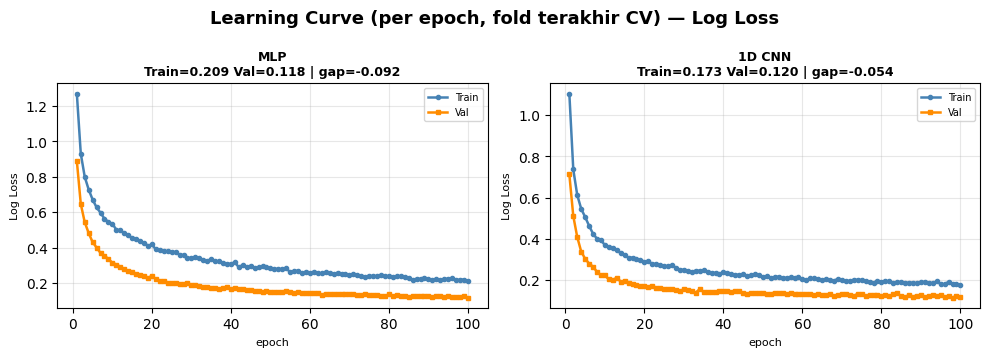

📊 Plot disimpan → ./results/images/learning_curve_dl_accuracy_hpo.png


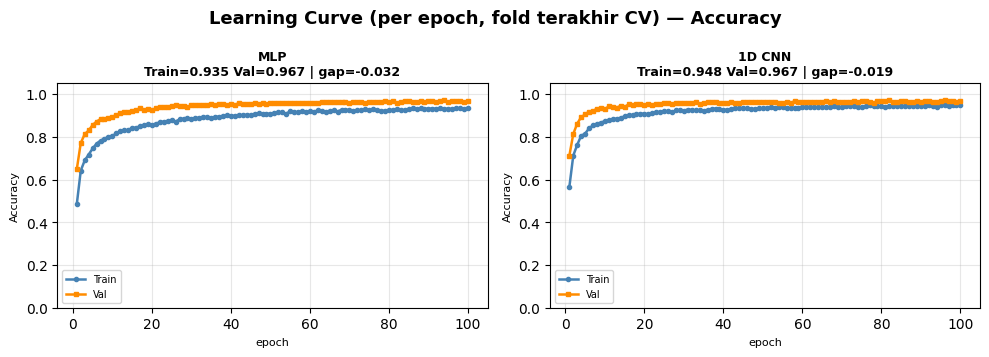

In [79]:
# ════════════════════════════════════════════════════════════
# 📈 Learning curve DL — loss & accuracy PER EPOCH (train vs validation)
# ════════════════════════════════════════════════════════════
# Diagnostik DL yang lazim: kurva training-history dari best model tiap arsitektur
# (history fold TERAKHIR tiap model dari 5-fold CV). Gap train↔val di epoch akhir = indikasi overfit.
import os
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("./results/images", exist_ok=True)
os.makedirs("./results/csv", exist_ok=True)

hist_models = [r for r in all_best if r.get("history")]
PANELS = [("loss", "val_loss", "Log Loss"), ("accuracy", "val_accuracy", "Accuracy")]

if not hist_models:
    print("⚠️  Belum ada history di all_best. Jalankan sel training dulu.")
else:
    n = len(hist_models)
    for tr_key, va_key, title in PANELS:
        ncols = min(3, n)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows), squeeze=False)
        axes = axes.ravel()
        for ax, r in zip(axes, hist_models):
            h = r["history"]; ep = np.arange(1, len(h[tr_key]) + 1)
            ax.plot(ep, h[tr_key], "o-", color="steelblue", lw=1.8, ms=3, label="Train")
            ax.plot(ep, h[va_key], "s-", color="darkorange", lw=1.8, ms=3, label="Val")
            gap = (h[va_key][-1] - h[tr_key][-1]) if tr_key == "loss" else (h[tr_key][-1] - h[va_key][-1])
            ax.set_title(f"{r['model']}\nTrain={h[tr_key][-1]:.3f} Val={h[va_key][-1]:.3f} | gap={gap:+.3f}",
                         fontsize=9, fontweight="bold")
            ax.set_xlabel("epoch", fontsize=8); ax.set_ylabel(title, fontsize=8)
            ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
            if tr_key == "accuracy":
                ax.set_ylim(0, 1.05)
        for ax in axes[n:]:
            ax.axis("off")
        fig.suptitle(f"Learning Curve (per epoch, fold terakhir CV) — {title}", fontsize=13, fontweight="bold")
        fig.tight_layout()
        out = f"./results/images/learning_curve_dl_{tr_key}_hpo.png"
        fig.savefig(out, dpi=120, bbox_inches="tight")
        print(f"📊 Plot disimpan → {out}")
        plt.show()


### 3.5 Gap Train vs Val (epoch terakhir)

Selisih train↔val pada epoch terakhir tiap model. `overfit_gap > 0` = indikasi overfit (Loss = Val−Train; Accuracy = Train−Val).


In [80]:
# ════════════════════════════════════════════════════════════
# 📋 Gap Train vs Val (epoch terakhir) — loss & accuracy
# ════════════════════════════════════════════════════════════
# overfit_gap: > 0 = indikasi overfit (loss = Val−Train; accuracy = Train−Val).
import pandas as pd

rows = []
for r in all_best:
    h = r.get("history")
    if not h:
        continue
    tr_l, va_l = h["loss"][-1], h["val_loss"][-1]
    tr_a, va_a = h["accuracy"][-1], h["val_accuracy"][-1]
    rows.append({
        "Model": r["model"],
        "Train Loss": tr_l, "Val Loss": va_l, "Loss Gap (Val-Train)": va_l - tr_l,
        "Train Acc": tr_a, "Val Acc": va_a, "Acc Gap (Train-Val)": tr_a - va_a,
    })

gap_df = pd.DataFrame(rows)
display(gap_df.style
        .format({c: "{:.4f}" for c in gap_df.columns if c != "Model"})
        .background_gradient(cmap="Reds", subset=["Loss Gap (Val-Train)", "Acc Gap (Train-Val)"]))
gap_df.to_csv("./results/csv/learning_curve_gap_dl_hpo.csv", index=False)
print("✅ Saved: ./results/csv/learning_curve_gap_dl_hpo.csv")


,Model,Train Loss,Val Loss,Loss Gap (Val-Train),Train Acc,Val Acc,Acc Gap (Train-Val)
0,MLP,0.2094,0.1179,-0.0915,0.9354,0.9671,-0.0317
1,1D CNN,0.1733,0.1195,-0.0537,0.9484,0.9671,-0.0187


✅ Saved: ./results/csv/learning_curve_gap_dl_hpo.csv


## 4. Kurva Training DL (single run — 1× fit)

Evaluasi di atas memakai **5-fold CV** (metrik mean±std + OOF). Di sini, khusus untuk
**menampilkan kurva loss & accuracy per epoch** yang bersih, tiap model best dilatih
**SEKALI saja** pada satu split train/val stratified (85/15). Kurva ini hanya untuk
visualisasi pola training (under/overfit), bukan untuk angka metrik akhir.

> 💾 **Checkpoint**: history training disimpan ke `dl_training_curves_{slug}.pkl`. Re-run akan memuat dari disk tanpa melatih ulang. Set `VIZ_FORCE = True` untuk melatih ulang (checkpoint juga otomatis invalid bila params/arsitektur/`VIZ_VAL_SIZE` berubah).


▶ Training MLP (1× run) — epochs=100 ...
   selesai: 100 epoch (val_loss=0.1635, val_acc=0.9489)
▶ Training 1D CNN (1× run) — epochs=100 ...
   selesai: 86 epoch (val_loss=0.1589, val_acc=0.9548)
💾 Kurva training disimpan → ./results/checkpoints/dl_training_curves_dropB_EC_smoteenn_random.pkl


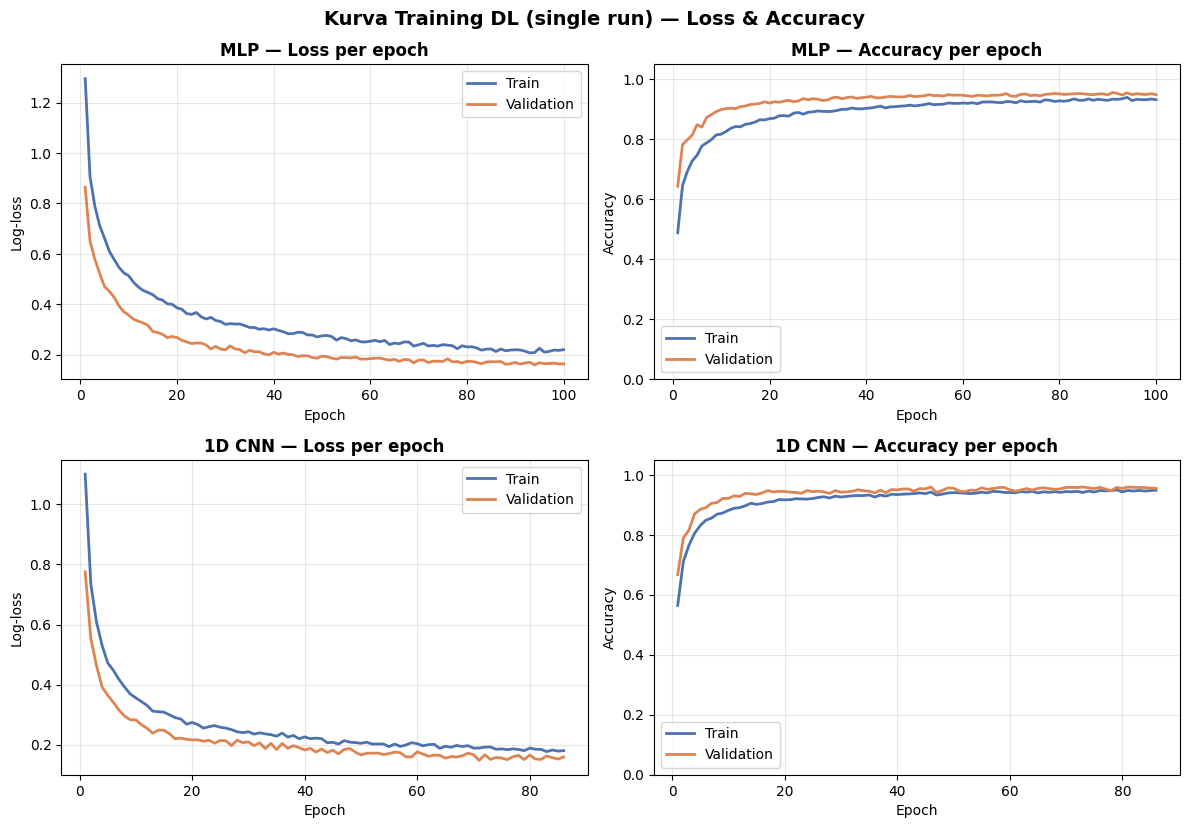

✅ Saved: ./results/images/dl_training_curves_single_run.png


In [81]:
# ════════════════════════════════════════════════════════════
# 📈 Kurva Training DL — single run (1× train/val split)
# ════════════════════════════════════════════════════════════
# Tiap model best (params dari all_best) dilatih SEKALI pada satu split train/val,
# lalu history per-epoch diplot: Loss (kiri) & Accuracy (kanan), train vs validation.
#
# 💾 Checkpoint: history training disimpan ke pickle (key = config_slug + params +
# VIZ_VAL_SIZE). Re-run → dimuat dari disk tanpa melatih ulang. Set VIZ_FORCE=True
# untuk melatih ulang (mis. setelah ganti params/arsitektur).
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Map nama model -> (build_fn, conv) supaya arsitekturnya sama dgn yang di-CV.
_BUILDERS = {"MLP": (build_mlp, False), "1D CNN": (build_cnn1d, True)}

# Satu split train/val stratified (khusus visualisasi kurva, bukan untuk metrik).
VIZ_VAL_SIZE = 0.15
VIZ_FORCE    = False   # True = latih ulang & timpa checkpoint
VIZ_CKPT     = f"./results/checkpoints/dl_training_curves_{config_slug()}.pkl"
os.makedirs(os.path.dirname(VIZ_CKPT), exist_ok=True)

_tr_idx, _va_idx = train_test_split(
    np.arange(len(y)), test_size=VIZ_VAL_SIZE, stratify=y, random_state=42)

# Signature → invalidasi checkpoint bila params/arsitektur/split berubah.
_viz_sig = json.dumps({
    "val_size": VIZ_VAL_SIZE,
    "models": {r["model"]: r["params"] for r in all_best if r["model"] in _BUILDERS},
}, sort_keys=True, default=str)

histories = None
if not VIZ_FORCE and os.path.exists(VIZ_CKPT):
    with open(VIZ_CKPT, "rb") as f:
        _ck = pickle.load(f)
    if _ck.get("sig") == _viz_sig:
        histories = _ck["histories"]
        print(f"♻️  Kurva training dimuat ← {VIZ_CKPT} "
              f"({[n for n, _ in histories]}) — training dilewati.")
    else:
        print("ℹ️  Params/split berubah sejak checkpoint terakhir — training ulang.")

if histories is None:
    histories = []
    for r in all_best:
        name = r["model"]
        if name not in _BUILDERS:
            continue
        build_fn, conv = _BUILDERS[name]
        params = r["params"]
        X_tr_fit, y_tr_fit, X_va, y_va = prep_fold(
            _tr_idx, _va_idx, conv=conv, resampler=make_resampler())
        keras.backend.clear_session()
        model = build_fn(X_tr_fit.shape[1], n_classes, params)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                           restore_best_weights=True, verbose=0)
        print(f"▶ Training {name} (1× run) — epochs={params['epochs']} ...")
        h = model.fit(X_tr_fit, y_tr_fit, validation_data=(X_va, y_va),
                      epochs=params['epochs'], batch_size=params['batch_size'],
                      verbose=0, callbacks=[es])
        hist = {k: [float(v) for v in vals] for k, vals in h.history.items()}
        histories.append((name, hist))
        print(f"   selesai: {len(hist['loss'])} epoch "
              f"(val_loss={hist['val_loss'][-1]:.4f}, val_acc={hist['val_accuracy'][-1]:.4f})")
    if histories:
        with open(VIZ_CKPT, "wb") as f:
            pickle.dump({"sig": _viz_sig, "histories": histories}, f)
        print(f"💾 Kurva training disimpan → {VIZ_CKPT}")

if not histories:
    print("⚠️  all_best kosong — jalankan dulu sel training MLP & 1D CNN di atas.")
else:
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4.2 * n), squeeze=False)
    for row, (name, h) in enumerate(histories):
        ep = np.arange(1, len(h['loss']) + 1)
        # Loss
        axes[row][0].plot(ep, h['loss'], color='#4C72B0', lw=2, label='Train')
        axes[row][0].plot(ep, h['val_loss'], color='#DD8452', lw=2, label='Validation')
        axes[row][0].set_title(f"{name} — Loss per epoch", fontweight='bold')
        axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('Log-loss')
        axes[row][0].legend(); axes[row][0].grid(alpha=0.3)
        # Accuracy
        axes[row][1].plot(ep, h['accuracy'], color='#4C72B0', lw=2, label='Train')
        axes[row][1].plot(ep, h['val_accuracy'], color='#DD8452', lw=2, label='Validation')
        axes[row][1].set_title(f"{name} — Accuracy per epoch", fontweight='bold')
        axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylabel('Accuracy')
        axes[row][1].set_ylim(0, 1.05); axes[row][1].legend(); axes[row][1].grid(alpha=0.3)
    fig.suptitle("Kurva Training DL (single run) — Loss & Accuracy",
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    os.makedirs("./results/csv", exist_ok=True)
    out_path = "./results/images/dl_training_curves_single_run.png"
    fig.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {out_path}")

## Metrik & Kurva Tambahan (Balanced/Weighted, ROC, PR, Normalized CM)

Tambahan evaluasi **tanpa mengubah** sel/grafik existing:

- **Balanced Accuracy** + **Weighted** precision/recall/f1 (pelengkap metrik macro).
- **Kurva ROC** One-vs-Rest (per kelas + micro-average).
- **Kurva Precision-Recall** (per kelas + micro-average).
- **Confusion matrix ter-normalisasi** (baris = recall per kelas).

> Kurva ROC/PR memakai probabilitas OOF (`y_prob`) yang kini disimpan `evaluate_cv`.
> Bila checkpoint lama belum memuat `y_prob`, **rerun** sel-sel training di atas dulu
> (set `RESET_CHECKPOINT = True`) agar `y_prob` ikut tersimpan.

In [82]:
# ════════════════════════════════════════════════════════════
# ➕ Metrik tambahan — Balanced Accuracy + Weighted (Precision/Recall/F1)
# ════════════════════════════════════════════════════════════
# Dihitung dari prediksi OOF (y_true/y_pred) yang sudah tersimpan tiap model —
# TIDAK melatih ulang. Balanced Acc = rata-rata recall per kelas (cocok data
# imbalanced); Weighted = ditimbang support. F1 (macro) ditaruh sebagai pembanding.
import os
import pandas as pd
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score,
)

_rows = []
for r in all_best:
    if "y_true" not in r or "y_pred" not in r:
        continue
    yt, yp = r["y_true"], r["y_pred"]
    _rows.append({
        "Model"        : r["model"],
        "Balanced Acc" : balanced_accuracy_score(yt, yp),
        "Precision (w)": precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall (w)"   : recall_score(yt, yp, average="weighted", zero_division=0),
        "F1 (w)"       : f1_score(yt, yp, average="weighted", zero_division=0),
        "F1 (macro)"   : f1_score(yt, yp, average="macro", zero_division=0),
    })
extra_df = pd.DataFrame(_rows).sort_values("F1 (w)", ascending=False).reset_index(drop=True)
extra_df.index += 1
_fmt = {c: "{:.4f}" for c in extra_df.columns if c != "Model"}
display(extra_df.style.format(_fmt)
        .background_gradient(cmap="Greens",
                             subset=["Balanced Acc", "Precision (w)", "Recall (w)", "F1 (w)"]))

os.makedirs("./results/csv", exist_ok=True)
extra_df.to_csv("./results/csv/eval_extra_metrics_dl_hpo.csv", index=True)
print("✅ Saved: ./results/csv/eval_extra_metrics_dl_hpo.csv")

,Model,Balanced Acc,Precision (w),Recall (w),F1 (w),F1 (macro)
1,1D CNN,0.9635,0.9664,0.9653,0.9656,0.9560
2,MLP,0.9594,0.9656,0.9647,0.9649,0.9556


✅ Saved: ./results/csv/eval_extra_metrics_dl_hpo.csv


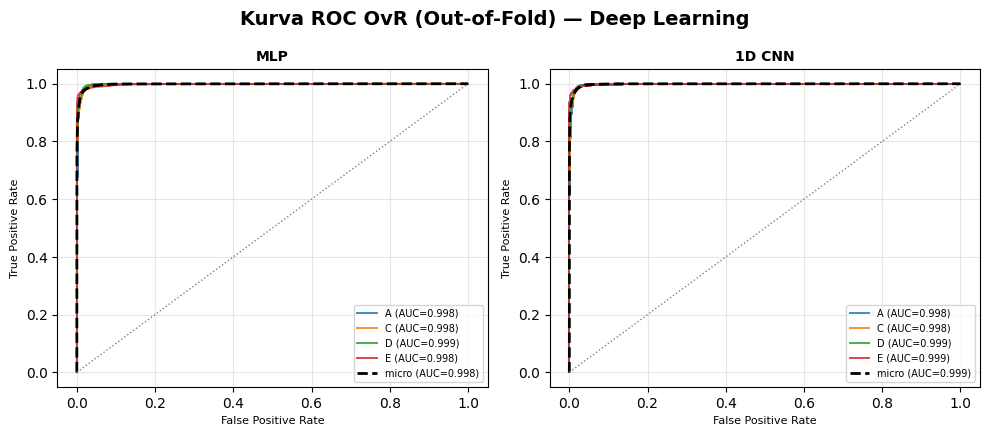

✅ Saved: ./results/images/roc_curve_dl_hpo.png


In [83]:
# ════════════════════════════════════════════════════════════
# 📈 Kurva ROC One-vs-Rest (OOF) — per kelas + micro-average, tiap model
# ════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

_cls_names = [str(c) for c in label_encoder.classes_]
_classes   = np.unique(y)
models_p = [r for r in all_best if r.get("y_prob") is not None]

if not models_p:
    print("⚠️  Belum ada 'y_prob' di all_best. Rerun sel training (evaluate_cv kini "
          "menyimpan probabilitas OOF; set RESET_CHECKPOINT=True), lalu ulangi sel ini.")
else:
    n = len(models_p); ncols = min(3, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, models_p):
        yt = np.asarray(r["y_true"])
        Y  = label_binarize(yt, classes=_classes)
        P  = np.asarray(r["y_prob"])
        for i, cn in enumerate(_cls_names):
            fpr, tpr, _ = roc_curve(Y[:, i], P[:, i])
            ax.plot(fpr, tpr, lw=1.4, alpha=0.85, label=f"{cn} (AUC={auc(fpr, tpr):.3f})")
        fpr_mi, tpr_mi, _ = roc_curve(Y.ravel(), P.ravel())
        ax.plot(fpr_mi, tpr_mi, "k--", lw=2, label=f"micro (AUC={auc(fpr_mi, tpr_mi):.3f})")
        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1)
        ax.set_title(r["model"], fontsize=10, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=8)
        ax.set_ylabel("True Positive Rate", fontsize=8)
        ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Kurva ROC OvR (Out-of-Fold) — Deep Learning", fontsize=14, fontweight="bold")
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/roc_curve_dl_hpo.png"
    fig.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")

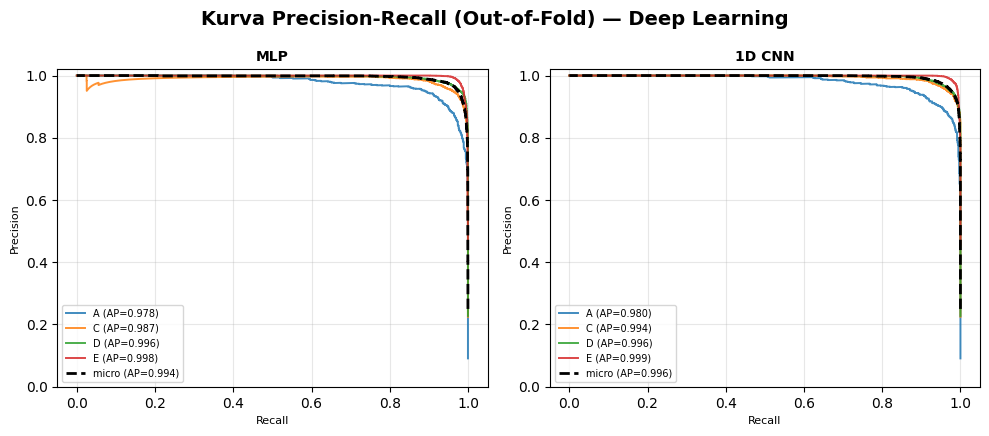

✅ Saved: ./results/images/pr_curve_dl_hpo.png


In [84]:
# ════════════════════════════════════════════════════════════
# 📈 Kurva Precision-Recall (OOF) — per kelas + micro-average, tiap model
# ════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

_cls_names = [str(c) for c in label_encoder.classes_]
_classes   = np.unique(y)
models_p = [r for r in all_best if r.get("y_prob") is not None]

if not models_p:
    print("⚠️  Belum ada 'y_prob' di all_best. Rerun sel training lalu ulangi sel ini.")
else:
    n = len(models_p); ncols = min(3, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, models_p):
        yt = np.asarray(r["y_true"])
        Y  = label_binarize(yt, classes=_classes)
        P  = np.asarray(r["y_prob"])
        for i, cn in enumerate(_cls_names):
            prec, rec, _ = precision_recall_curve(Y[:, i], P[:, i])
            ap = average_precision_score(Y[:, i], P[:, i])
            ax.plot(rec, prec, lw=1.4, alpha=0.85, label=f"{cn} (AP={ap:.3f})")
        prec_mi, rec_mi, _ = precision_recall_curve(Y.ravel(), P.ravel())
        ap_mi = average_precision_score(Y, P, average="micro")
        ax.plot(rec_mi, prec_mi, "k--", lw=2, label=f"micro (AP={ap_mi:.3f})")
        ax.set_title(r["model"], fontsize=10, fontweight="bold")
        ax.set_xlabel("Recall", fontsize=8); ax.set_ylabel("Precision", fontsize=8)
        ax.set_ylim(0, 1.02); ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Kurva Precision-Recall (Out-of-Fold) — Deep Learning", fontsize=14, fontweight="bold")
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/pr_curve_dl_hpo.png"
    fig.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")

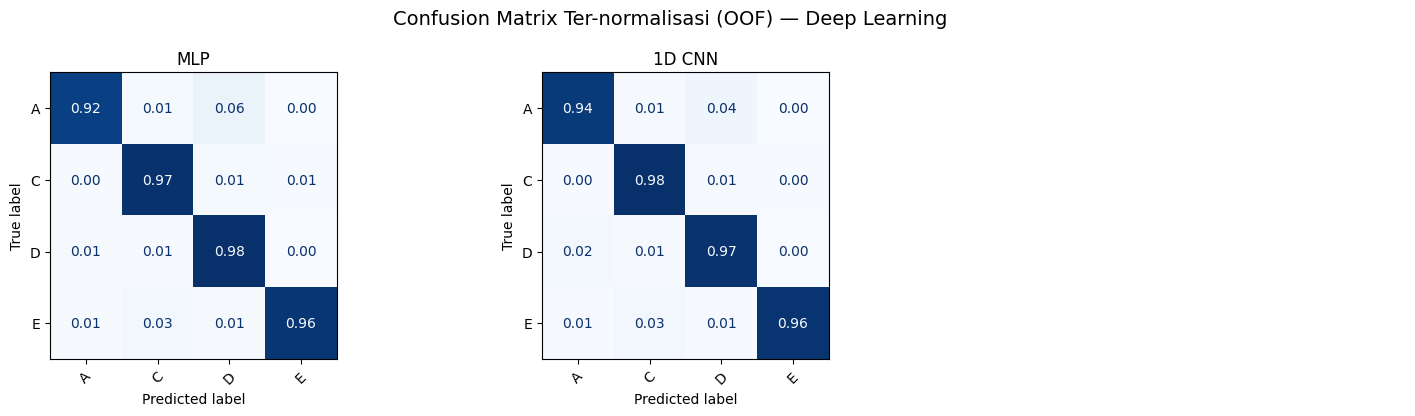

✅ Saved: ./results/images/confusion_matrix_normalized_dl_hpo.png


In [85]:
# ════════════════════════════════════════════════════════════
# 🔢 Confusion Matrix TER-NORMALISASI (baris = recall per kelas) — OOF
# ════════════════════════════════════════════════════════════
# Versi normalisasi (normalize='true') dari confusion matrix existing. Tiap baris
# jadi proporsi → mudah baca performa per kelas saat support antar-kelas timpang.
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_cls_names = list(label_encoder.classes_)
_labels = np.arange(len(_cls_names))
models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]

if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best.")
else:
    n = len(models_cm); ncols = 3; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=_labels, normalize="true")
        ConfusionMatrixDisplay(cm, display_labels=_cls_names).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
        ax.set_title(r["model"]); ax.tick_params(axis="x", rotation=45)
    for ax in axes[len(models_cm):]:
        ax.axis("off")
    fig.suptitle("Confusion Matrix Ter-normalisasi (OOF) — Deep Learning", fontsize=14)
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/confusion_matrix_normalized_dl_hpo.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")